In [1]:
import sys
sys.path.append("..")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import SuperconductorDataLoader
from src.preprocessor import DataPreprocessor

In [3]:
sns.set_theme(style="whitegrid")

In [4]:
loader = SuperconductorDataLoader("../data/raw/train.csv")

In [5]:
df = loader.load()
loader.validate(df)
df.head()

Loaded 21263 rows from train.csv
Data validation passed


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [6]:
print(f"Shape: {df.shape}")
print(f"\nSpaltennamen (erste 10):\n{list(df.columns[:10])}")
print(f"\nDatentypen:\n{df.dtypes.value_counts()}")
print(f"\nNaN-Werte gesamt: {df.isna().sum().sum()}")

Shape: (21263, 82)

Spaltennamen (erste 10):
['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass']

Datentypen:
float64    79
int64       3
Name: count, dtype: int64

NaN-Werte gesamt: 0


In [7]:
df["critical_temp"].describe()

count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64

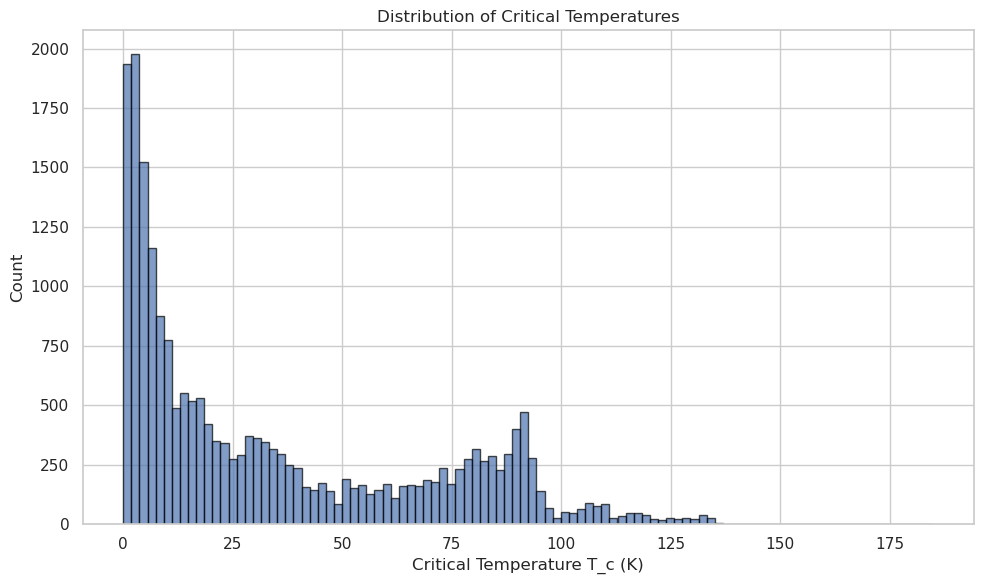

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["critical_temp"], bins=100, edgecolor="black", alpha=0.7)
ax.set_xlabel("Critical Temperature T_c (K)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Critical Temperatures")
plt.tight_layout()
plt.show()

he data frame has 21,263 rows and 82 columns
Min_Tc =  0.000210 K
max_Tc = 185.000 K
mean_Tc = 34.421219 K
The distribution is right-skewed and asymmetric. If one were to consider the small peak around 80 K as equivalent to the one around 2 K, one could speak of a right-skewed bimodal distribution.
This is consistent with Hamidieh's explanations.
Physical interpretation: This second peak at ~80 K corresponds to cuprates (high-temperature superconductors such as YBCO), which have a significantly higher T_c than conventional superconductors.

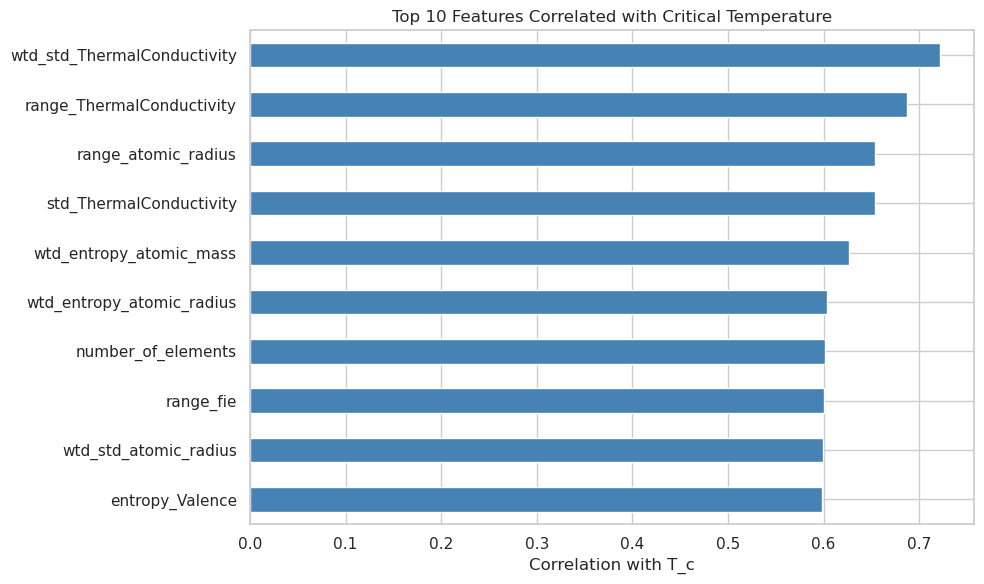

In [9]:
correlations = df.corr()["critical_temp"].sort_values(ascending=False)
top_features = correlations[1:11]  # exclude critical_temp itself

fig, ax = plt.subplots(figsize=(10, 6))
top_features.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Correlation with T_c")
ax.set_title("Top 10 Features Correlated with Critical Temperature")
plt.tight_layout()
plt.show()

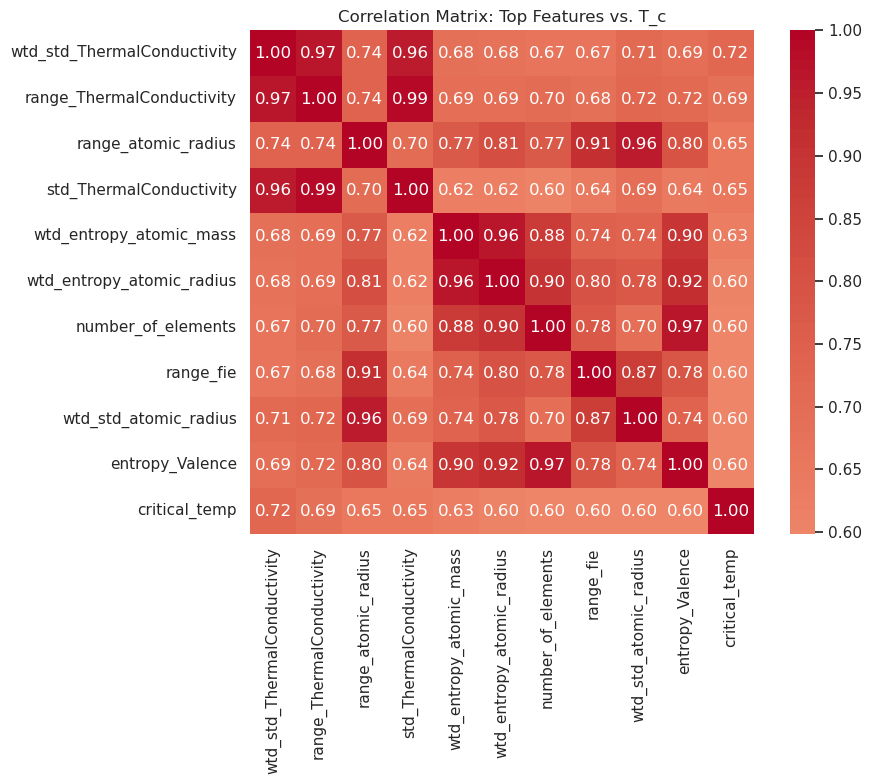

In [10]:
top_cols = list(top_features.index) + ["critical_temp"]
corr_matrix = df[top_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix: Top Features vs. T_c")
plt.tight_layout()
plt.show()

In [11]:
corr_matrix_full = df.corr()
corr_with_target = corr_matrix_full["critical_temp"].sort_values(ascending=False)
pd.set_option("display.max_rows", None)

corr_abs = corr_with_target[1:].abs().sort_values(ascending=False)
corr_abs

wtd_std_ThermalConductivity        0.721271
range_ThermalConductivity          0.687654
range_atomic_radius                0.653759
std_ThermalConductivity            0.653632
wtd_mean_Valence                   0.632401
wtd_entropy_atomic_mass            0.626930
wtd_gmean_Valence                  0.615653
wtd_entropy_atomic_radius          0.603494
number_of_elements                 0.601069
range_fie                          0.600790
mean_Valence                       0.600085
wtd_std_atomic_radius              0.599199
entropy_Valence                    0.598591
wtd_entropy_Valence                0.589664
wtd_std_fie                        0.582013
gmean_Valence                      0.573068
entropy_fie                        0.567817
wtd_entropy_FusionHeat             0.563244
std_atomic_radius                  0.559629
entropy_atomic_radius              0.558937
entropy_FusionHeat                 0.552709
entropy_atomic_mass                0.543619
std_fie                         

In [12]:
pd.reset_option("display.max_rows")

### Physical Interpretation of the Features Most Strongly Correlated with T_c

The features most strongly correlated with T_c can all 
be explained in terms of solid-state physics:

1. **Thermal conductivity (wtd_std, range, std)**: 
   In BCS theory, superconductivity is a phonon-mediated Cooper pair formation. 
   Thermal conductivity is directly linked to phonon transport — high scattering (std) indicates a variety of phonon modes, which promotes electron-phonon coupling.

2. **Atomic radius**: 
   Determines the lattice constant and thus the overlap of the electron shells. 
   Larger atomic radii result in broader bands and alter the density of states at the Fermi edge (DOS), which is directly incorporated into the BCS formula for T_c.


3. **Valence electrons**: 
   The number of valence electrons determines the electronic band structure 
   and the DOS at the Fermi edge. Higher DOS → more pair formation → higher T_c.

4. **Atomic mass**: 
   In the BCS model, the isotope effect holds: T_c $\propto 1/\sqrt M$. 
   Heavier atoms → lower phonon frequencies → lower T_c.

5. **Number of elements**: 
   More complex compounds (especially cuprates with 4 or more elements) 
   achieve higher T_c — which explains high-temperature superconductivity.


In [13]:
df_mat = pd.read_csv("../data/raw/unique_m.csv")
df_mat.head()

,H,He,Li,Be,B,C,N,O,F,Ne,...,Au,Hg,Tl,Pb,Bi,Po,At,Rn,critical_temp,material
0,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,29.0,Ba0.2La1.8Cu1O4
1,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,26.0,Ba0.1La1.9Ag0.1Cu0.9O4
2,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,19.0,Ba0.1La1.9Cu1O4
3,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,22.0,Ba0.15La1.85Cu1O4
4,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,23.0,Ba0.3La1.7Cu1O4


In [14]:
df_mat.shape

(21263, 88)

In [15]:

df_mat["critical_temp"] = df["critical_temp"]

# Material class: Cuprate (contains Cu)?
df_mat["is_cuprate"] = (df_mat["Cu"] > 0) & (df_mat["O"] > 0)

# Iron pniktid (contains Fe and As/Se)?
df_mat["is_iron_pnictide"] = (df_mat["Fe"] > 0) & ((df_mat["As"] > 0) | (df_mat["Se"] > 0))

# Number of elements per material
element_columns = df_mat.columns[:87]
df_mat["n_elements"] = (df_mat[element_columns] > 0).sum(axis=1)

# Überblick
print(f"Cuprate: {df_mat['is_cuprate'].sum()} materials")
print(f"Iron pnictide: {df_mat['is_iron_pnictide'].sum()} materials")
print(f"Other: {(~df_mat['is_cuprate'] & ~df_mat['is_iron_pnictide']).sum()} materials")

Cuprate: 10532 materials
Iron pniktid: 1682 materials
Other: 9049 materials


In [17]:
for label, mask in [("Cuprate", df_mat["is_cuprate"]), 
                    ("Iron pnictide", df_mat["is_iron_pnictide"]),
                    ("Other", ~df_mat["is_cuprate"] & ~df_mat["is_iron_pnictide"])]:
    tc = df_mat.loc[mask, "critical_temp"]
    print(f"{label:15s}: n={len(tc):6d}, median={tc.median():.1f} K, mean={tc.mean():.1f} K, max={tc.max():.1f} K")



Cuprate        : n= 10532, median=63.1 K, mean=59.9 K, max=143.0 K
Iron pniktid   : n=  1682, median=20.0 K, mean=22.0 K, max=65.0 K
Other          : n=  9049, median=4.5 K, mean=7.1 K, max=185.0 K


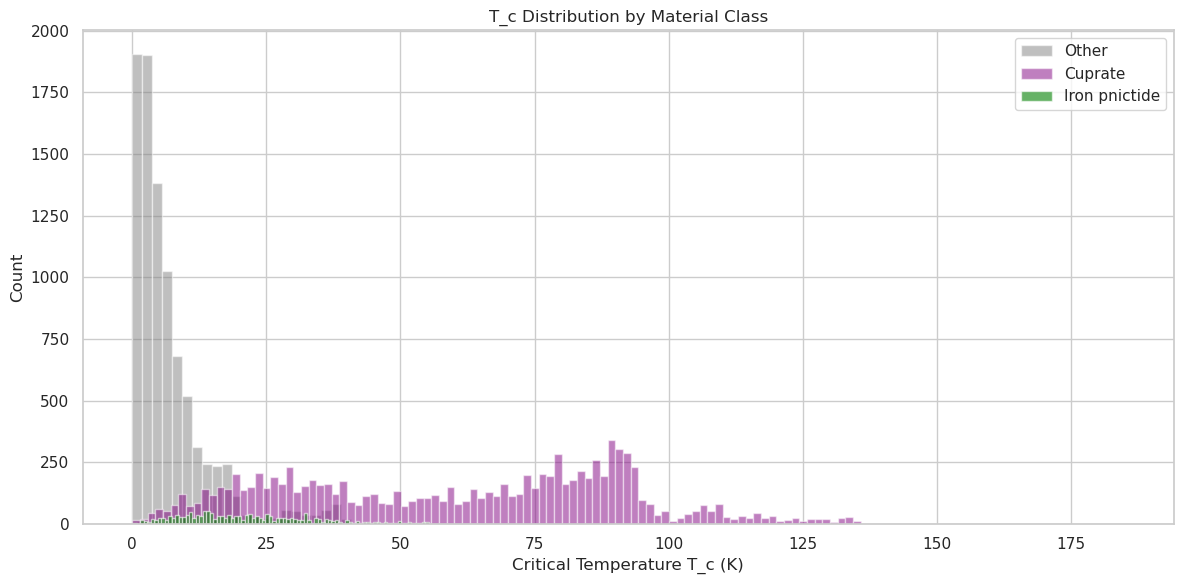

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))


ax.hist(df_mat.loc[~df_mat["is_cuprate"] & ~df_mat["is_iron_pnictide"], "critical_temp"], 
        bins=100, alpha=0.5, label="Other", color="gray")

ax.hist(df_mat.loc[df_mat["is_cuprate"], "critical_temp"], 
        bins=100, alpha=0.5, label="Cuprate", color="purple")
ax.hist(df_mat.loc[df_mat["is_iron_pnictide"], "critical_temp"], 
        bins=100, alpha=0.6, label="Iron pnictide", color="green")

ax.set_xlabel("Critical Temperature T_c (K)")
ax.set_ylabel("Count")
ax.set_title("T_c Distribution by Material Class")
ax.legend()
plt.tight_layout()
plt.show()

### Material Class Analysis: T_c Distribution by Superconductor Family

The dataset was classified into three major superconductor families based 
on elemental composition:

1. **Cuprates** (Cu and O present): 10,532 materials
2. **Iron Pnictides** (Fe and As/Se present): 1,682 materials  
3. **Others** (conventional superconductors): 9,049 materials

#### Key Observations

- **Cuprates** exhibit the highest critical temperatures (median: 63.1 K, 
  max: 143 K), explaining the prominent peak at ~80 K in the overall 
  T_c distribution. However, they show a very broad spread, ranging 
  from low to extremely high T_c values. This is because not every 
  Cu-O-containing compound is automatically a high-T_c superconductor – 
  stoichiometry and crystal structure play a decisive role.

- **Iron Pnictides** occupy an intermediate regime (median: 20.0 K, 
  range: 1–65 K) with a peak around 10 K. Although they are less 
  numerous, they represent an important class of unconventional 
  superconductors.

- **Conventional Superconductors (Others)** are concentrated in the 
  low-temperature range (0.1–20 K, median: 4.5 K), explaining the 
  primary peak at ~2 K in the overall distribution. Interestingly, 
  a smaller cluster appears between 27 and 35 K, which likely 
  corresponds to unconventional superconductors such as MgB₂ (T_c ≈ 39 K) 
  or similar non-cuprate materials with unexpectedly high T_c values.

#### Implications for Modeling

The bimodal distribution of T_c observed in the initial histogram 
can be directly attributed to the superposition of these material 
classes: conventional superconductors dominate the low-T_c peak, 
while cuprates dominate the high-T_c peak. The broad spread within 
each class, particularly among cuprates, demonstrates that elemental 
composition alone is insufficient for precise T_c prediction. A 
combination of all 81 engineered features capturing thermodynamic, 
structural, and electronic properties is necessary to capture the 
complex interplay governing superconductivity.

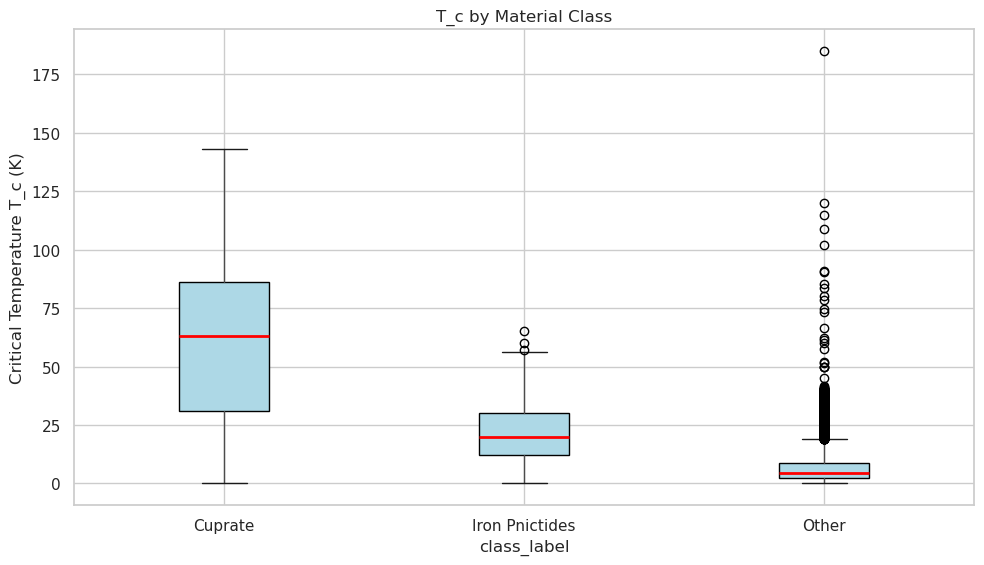

In [20]:
df_mat["class_label"] = "Other"
df_mat.loc[df_mat["is_cuprate"], "class_label"] = "Cuprate"
df_mat.loc[df_mat["is_iron_pnictide"], "class_label"] = "Iron Pnictides"

fig, ax = plt.subplots(figsize=(10, 6))
df_mat.boxplot(column="critical_temp", by="class_label", ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor="lightblue"),
               medianprops=dict(color="red", linewidth=2))
ax.set_ylabel("Critical Temperature T_c (K)")
ax.set_title("T_c by Material Class")
plt.suptitle("")  
plt.tight_layout()
plt.show()


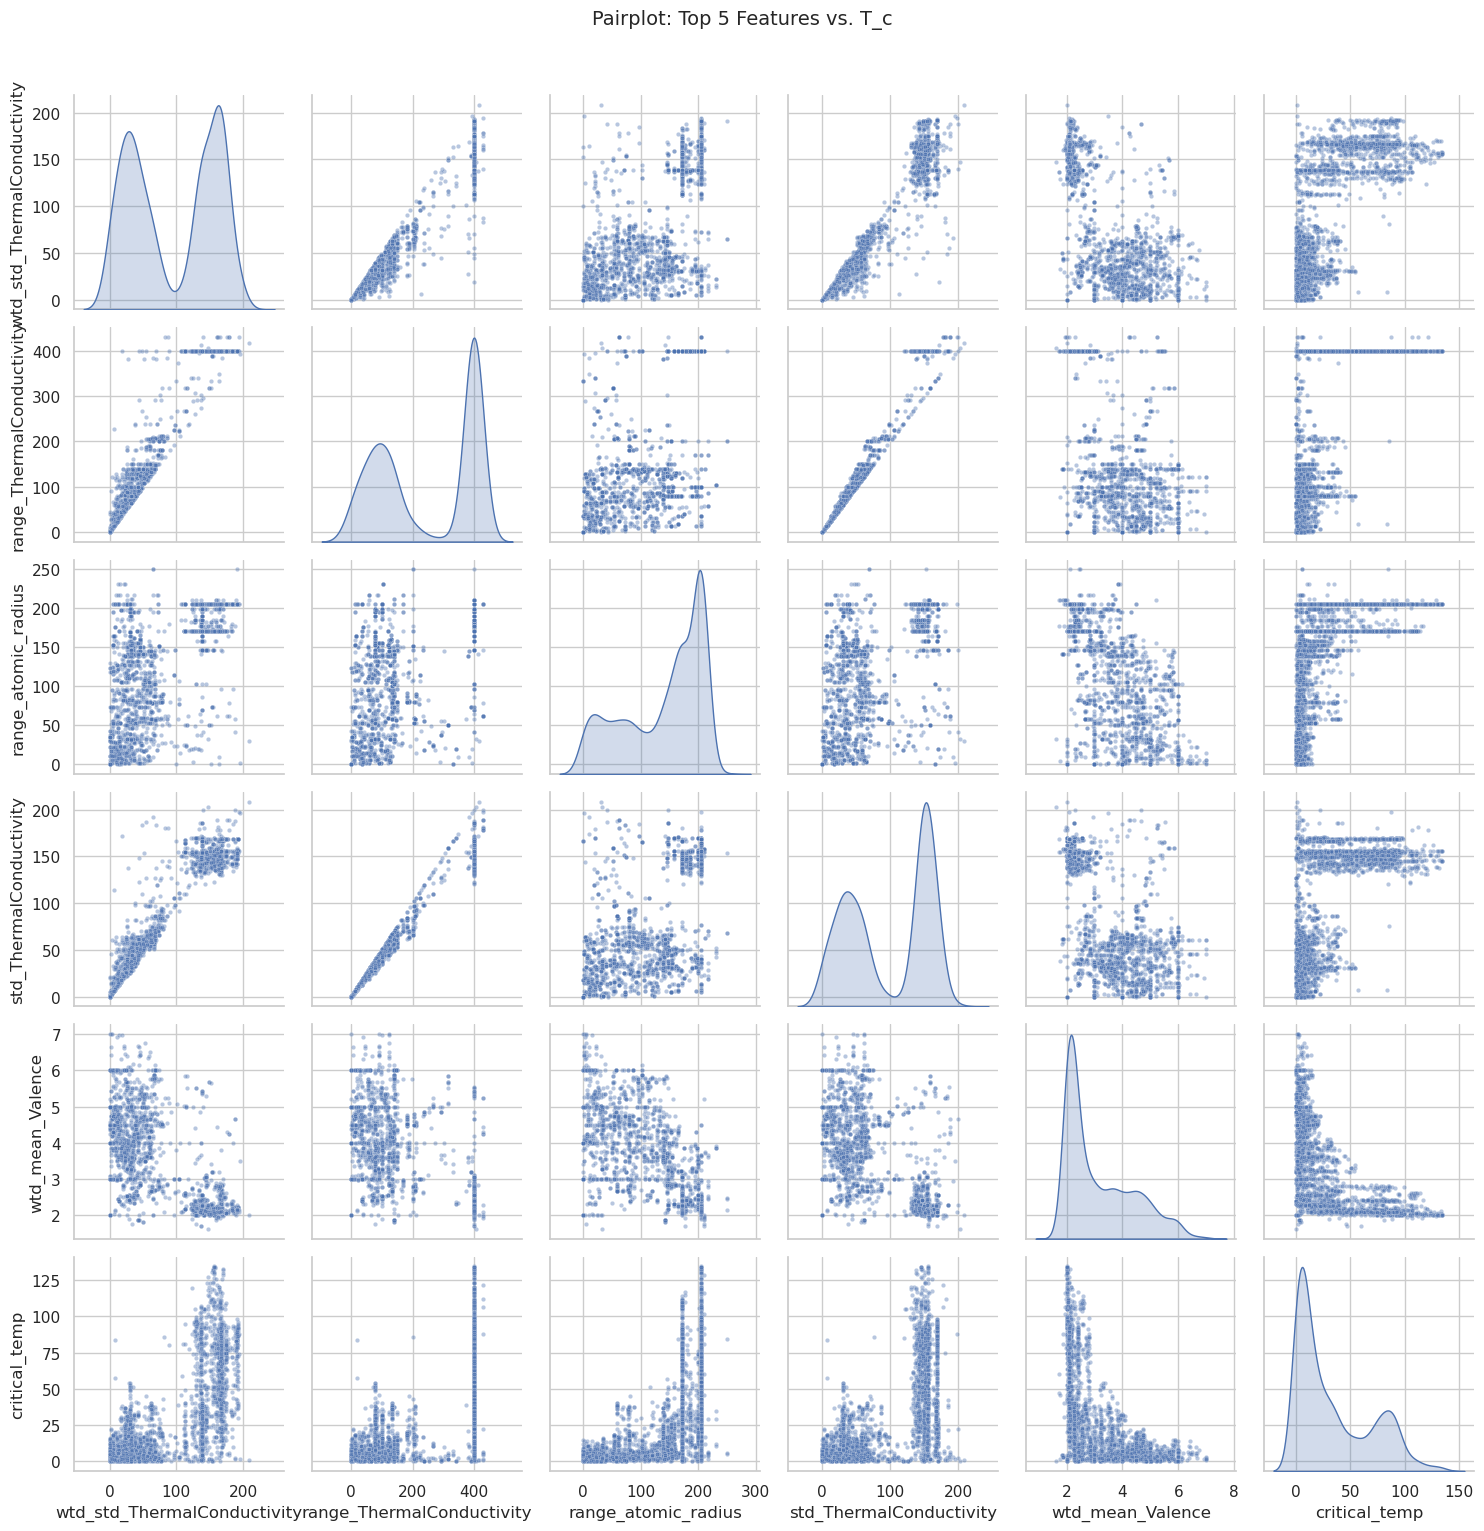

In [23]:
# Top 5 Features w.r.t. correlation with T_c
top5 = list(corr_abs.head(5).index)
plot_cols = top5 + ["critical_temp"]

# For Performance: Take a Sample
df_sample = df[plot_cols ].sample(n=3000, random_state=42)

# Pairplot
g = sns.pairplot(
    df_sample,
    vars=plot_cols,
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 10},
    height=2.5
)
g.fig.suptitle("Pairplot: Top 5 Features vs. T_c", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Pairplot Analysis: Top 5 Features

A pairplot was generated for the top 5 features most correlated with 
T_c, using a random sample of 3,000 materials for computational 
efficiency.

#### Key Observations

- **Bimodal distributions across all features**: All five top features 
  exhibit bimodal distributions, indicating that they implicitly encode 
  information about material class (high-T_c cuprates vs. conventional 
  superconductors). The bimodality is most pronounced in 
  `std_ThermalConductivity` and least pronounced in `wtd_mean_Valence`, 
  suggesting that thermal conductivity features carry strong 
  discriminating power between material families.

- **Multicollinearity detected**: A clear linear relationship is 
  observed between `std_ThermalConductivity` and 
  `range_ThermalConductivity`. This is expected, as both features are 
  derived from the same underlying quantity (thermal conductivity of 
  the constituent elements). This multicollinearity is unlikely to 
  affect tree-based models (e.g., Random Forest) but may destabilize 
  coefficient estimates in linear regression models. This finding 
  suggests that feature selection or dimensionality reduction could 
  improve the linear baseline model.

#### Implications for Modeling

The bimodal nature of key features indicates that the dataset contains 
two distinct populations with fundamentally different physical 
characteristics. A well-designed model should be able to leverage this 
separation. The presence of multicollinearity among top features 
highlights the importance of comparing models that handle correlated 
features differently (e.g., Random Forest vs. Linear Regression).